# 04 - FDA–DEA Descriptive Comparisons

## Purpose

This notebook compares the FDA submission-event backbone to the first-pass DEA linkage layer in order to decide which **controlled-substance outcome series** is most defensible for the next stage of the thesis.

This is a **pre-event-study diagnostic notebook**, not the final causal design. The goal is to understand what the linked data can support, where the classifications are weakest, and how much the results depend on sample definition and DEA confidence tier.

## Main inputs

1. `data/processed/fda_backbone.csv`
   - the master FDA submission-event panel built from the March 2026 Drugs@FDA extract
2. `data/intermediate/fda_dea_controlled_substance_linkage.csv`
   - the intended row-level FDA+DEA linkage export from notebook 03

## What this notebook can and cannot answer

This notebook can describe how **observed FDA submission-event activity** linked to DEA-controlled substances behaves over time under different sample definitions. It can also show how sensitive those patterns are to using only confident DEA matches versus broader linkage rules.

This notebook cannot prove historical schedule-at-approval, recover perfect product-level controlled-substance status, or identify a causal effect of PDUFA. The DEA linkage remains a **current, ingredient-level, non-historical enrichment layer**, and the FDA data remain a **submission-event panel**, not an automatic drug-level series.


## Setup

The first code block only sets up imports, paths, plotting conventions, and category labels. Keeping those objects explicit at the top makes the rest of the notebook easier to audit and reduces the temptation to hide assumptions later in the workflow.

In [1]:
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    """Walk upward until the thesis repo root is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "logs" / "thesis_context.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the econ580-thesis repository root from the current working directory.")


plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ROOT = find_repo_root(Path.cwd().resolve())
BACKBONE_PATH = ROOT / "data" / "processed" / "fda_backbone.csv"
LINKED_PATH = ROOT / "data" / "intermediate" / "fda_dea_controlled_substance_linkage.csv"
INGREDIENT_AUDIT_PATH = ROOT / "data" / "intermediate" / "fda_dea_active_ingredient_linkage_audit.csv"
TOKEN_AUDIT_PATH = ROOT / "data" / "intermediate" / "fda_dea_ingredient_token_audit.csv"

KEY_COLS = ["ApplNo", "SubmissionType", "SubmissionNo"]
PLOT_YEAR_MIN = 1960
PLOT_YEAR_MAX = 2025
PRIMARY_POLICY_YEAR = 1992
SECONDARY_POLICY_YEAR = 1984

DEA_STATUS_ORDER = [
    "confident_scheduled_controlled_substance_match",
    "list_i_chemical_only_match",
    "possible_parent_or_isomer_candidate_only",
    "no_active_ingredient_available_in_fda_backbone",
    "no_dea_signal_from_first_pass",
]

DEA_STATUS_LABELS = OrderedDict([
    ("confident_scheduled_controlled_substance_match", "Confident scheduled match"),
    ("list_i_chemical_only_match", "List I only"),
    ("possible_parent_or_isomer_candidate_only", "Candidate only / uncertain"),
    ("no_active_ingredient_available_in_fda_backbone", "No active ingredient in FDA backbone"),
    ("no_dea_signal_from_first_pass", "No DEA signal"),
])

DEA_STATUS_COLORS = OrderedDict([
    ("confident_scheduled_controlled_substance_match", "#b22222"),
    ("list_i_chemical_only_match", "#c97b00"),
    ("possible_parent_or_isomer_candidate_only", "#7a6ad8"),
    ("no_active_ingredient_available_in_fda_backbone", "#8a8f98"),
    ("no_dea_signal_from_first_pass", "#d9dde3"),
])


## Load the sources and validate that the row-level linkage is usable

The notebook should start by checking whether the two main inputs are actually usable in the local working tree. That matters here because the FDA+DEA row-level file may exist either as a materialized CSV or as a Git LFS pointer.

If the row-level linkage file is not materialized locally, the notebook should **not** fail silently and it should **not** overwrite the file in place. The more transparent fallback is to rebuild the row-level working dataframe **in memory only** by merging the FDA backbone to the ingredient-level linkage audit exported by notebook 03.


In [2]:
def inspect_git_lfs_pointer(path: Path) -> dict:
    """Return metadata if a local file resolves to a Git LFS pointer rather than data."""
    with path.open("r", encoding="utf-8", errors="ignore") as handle:
        first_lines = [handle.readline().strip() for _ in range(3)]
    is_pointer = bool(first_lines) and first_lines[0].startswith("version https://git-lfs.github.com/spec/v1")
    metadata = {
        "path": str(path),
        "exists": path.exists(),
        "is_git_lfs_pointer": is_pointer,
        "pointer_line_1": first_lines[0] if len(first_lines) >= 1 else "",
        "pointer_line_2": first_lines[1] if len(first_lines) >= 2 else "",
        "pointer_line_3": first_lines[2] if len(first_lines) >= 3 else "",
    }
    return metadata

backbone_raw = pd.read_csv(BACKBONE_PATH, low_memory=False)
ingredient_audit = pd.read_csv(INGREDIENT_AUDIT_PATH, low_memory=False)
token_audit = pd.read_csv(TOKEN_AUDIT_PATH, low_memory=False)
linked_pointer_meta = inspect_git_lfs_pointer(LINKED_PATH)

if linked_pointer_meta["is_git_lfs_pointer"]:
    linked_raw = None
    linked_source_mode = "reconstructed_in_memory_from_backbone_plus_ingredient_audit"

    # Rebuild the row-level linkage transparently from the ingredient-level audit.
    analysis_df = backbone_raw.merge(
        ingredient_audit,
        on="ActiveIngredient_list",
        how="left",
        validate="m:1",
    )
else:
    linked_raw = pd.read_csv(LINKED_PATH, low_memory=False)
    linked_source_mode = "loaded_materialized_row_level_linkage_csv"
    analysis_df = linked_raw.copy()

# Preserve the FDA backbone as the authoritative row structure for this notebook.
for col in KEY_COLS + ["SubmissionType", "SubmissionStatus", "ApplType_clean", "ReviewPriority_clean"]:
    if col in analysis_df.columns:
        analysis_df[col] = analysis_df[col].astype("string").str.strip()

analysis_df["submission_status_year"] = pd.to_numeric(
    analysis_df["submission_status_year"], errors="coerce"
).astype("Int64")

# The ingredient-level audit does not contain a row for missing FDA ingredient strings,
# so those rows must be labeled explicitly after the merge.
analysis_df["dea_linkage_status"] = analysis_df["dea_linkage_status"].fillna(
    "no_active_ingredient_available_in_fda_backbone"
).astype("string")

for flag_col in [
    "dea_confident_controlled_match_flag",
    "dea_list_i_only_match_flag",
    "dea_possible_candidate_only_flag",
    "dea_uncertain_flag",
]:
    if flag_col in analysis_df.columns:
        analysis_df[flag_col] = analysis_df[flag_col].fillna(False).astype(bool)

source_summary = pd.DataFrame([
    {
        "dataset": "FDA backbone",
        "path": str(BACKBONE_PATH),
        "rows": len(backbone_raw),
        "columns": backbone_raw.shape[1],
        "status": "loaded",
        "note": "master submission-event panel",
    },
    {
        "dataset": "FDA+DEA row-level linkage",
        "path": str(LINKED_PATH),
        "rows": len(linked_raw) if linked_raw is not None else pd.NA,
        "columns": linked_raw.shape[1] if linked_raw is not None else pd.NA,
        "status": "git-lfs-pointer" if linked_raw is None else "loaded",
        "note": linked_source_mode,
    },
    {
        "dataset": "Ingredient-level DEA audit",
        "path": str(INGREDIENT_AUDIT_PATH),
        "rows": len(ingredient_audit),
        "columns": ingredient_audit.shape[1],
        "status": "loaded",
        "note": "used for explicit fallback / audit",
    },
    {
        "dataset": "Token-level DEA audit",
        "path": str(TOKEN_AUDIT_PATH),
        "rows": len(token_audit),
        "columns": token_audit.shape[1],
        "status": "loaded",
        "note": "used only for unmatched/candidate diagnostics",
    },
])

merge_validation_summary = pd.DataFrame([
    {
        "check": "FDA backbone duplicate submission-event keys",
        "value": int(backbone_raw.duplicated(KEY_COLS).sum()),
    },
    {
        "check": "Working analysis dataframe duplicate submission-event keys",
        "value": int(analysis_df.duplicated(KEY_COLS).sum()),
    },
    {
        "check": "Row-count difference: working dataframe minus backbone",
        "value": int(len(analysis_df) - len(backbone_raw)),
    },
    {
        "check": "Rows with missing DEA linkage status after explicit fill",
        "value": int(analysis_df["dea_linkage_status"].isna().sum()),
    },
    {
        "check": "Rows with missing ActiveIngredient_list",
        "value": int(analysis_df["ActiveIngredient_list"].isna().sum()),
    },
])

if int(analysis_df.duplicated(KEY_COLS).sum()) != 0:
    raise ValueError("The working dataframe is not unique on the submission-event key.")

if len(analysis_df) != len(backbone_raw):
    raise ValueError("The working dataframe no longer matches the FDA backbone row count.")

display(source_summary)
display(merge_validation_summary)


,dataset,path,rows,columns,status,note
0,FDA backbone,/Users/alexdelatorre/Desktop/econ580-thesis/da...,191265,59,loaded,master submission-event panel
1,FDA+DEA row-level linkage,/Users/alexdelatorre/Desktop/econ580-thesis/da...,<NA>,<NA>,git-lfs-pointer,reconstructed_in_memory_from_backbone_plus_ing...
2,Ingredient-level DEA audit,/Users/alexdelatorre/Desktop/econ580-thesis/da...,3202,23,loaded,used for explicit fallback / audit
3,Token-level DEA audit,/Users/alexdelatorre/Desktop/econ580-thesis/da...,4442,26,loaded,used only for unmatched/candidate diagnostics


,check,value
0,FDA backbone duplicate submission-event keys,0
1,Working analysis dataframe duplicate submissio...,0
2,Row-count difference: working dataframe minus ...,0
3,Rows with missing DEA linkage status after exp...,0
4,Rows with missing ActiveIngredient_list,5737


### Interpretation

The notebook now has a validated row-level working dataframe for analysis.

In this working tree, the intended row-level linkage CSV is not materialized as data; it resolves to a Git LFS pointer. Rather than writing over that file, the notebook rebuilds the row-level linkage **in memory only** from the FDA backbone plus the ingredient-level DEA audit. That is the transparent choice because it preserves the repository state while still allowing the descriptive comparison notebook to run cleanly.

The key checks above should all remain clean before any analysis starts:

- no duplicated submission-event keys in the working dataframe
- no row inflation relative to the FDA backbone
- explicit handling of rows with missing `ActiveIngredient_list`


## Audit the working variables before defining analysis series

Before constructing any sample definitions or outcome series, the notebook should inspect the actual fields available in memory. This avoids coding to imagined variable names and makes the eventual outcome recommendation traceable to the real data structure.


In [3]:
focus_columns = [
    "ApplNo",
    "SubmissionType",
    "SubmissionNo",
    "SubmissionStatus",
    "submission_status_year",
    "ApplType_clean",
    "ReviewPriority_clean",
    "is_approved",
    "is_original_submission",
    "ActiveIngredient_list",
    "dea_linkage_status",
    "dea_confident_controlled_match_flag",
    "dea_list_i_only_match_flag",
    "dea_possible_candidate_only_flag",
    "dea_uncertain_flag",
]

dtype_summary = pd.DataFrame({
    "column": focus_columns,
    "dtype": [str(analysis_df[col].dtype) for col in focus_columns],
})

critical_missingness = (
    analysis_df[focus_columns]
    .isna()
    .sum()
    .rename("missing_n")
    .reset_index().rename(columns={"index": "column"})
)
critical_missingness["missing_share"] = critical_missingness["missing_n"] / len(analysis_df)
critical_missingness = critical_missingness.sort_values(["missing_share", "missing_n"], ascending=False)

key_examples = analysis_df[KEY_COLS + ["SubmissionStatus", "submission_status_year", "ApplType_clean", "ActiveIngredient_list", "dea_linkage_status"]].head(10)

linkage_status_summary = (
    analysis_df["dea_linkage_status"]
    .value_counts(dropna=False)
    .rename_axis("dea_linkage_status")
    .reset_index(name="row_count")
)
linkage_status_summary["share_of_full_panel"] = linkage_status_summary["row_count"] / len(analysis_df)

field_distribution_summary = pd.DataFrame([
    {"field": "SubmissionStatus", "distinct_values": int(analysis_df["SubmissionStatus"].nunique(dropna=False))},
    {"field": "SubmissionType", "distinct_values": int(analysis_df["SubmissionType"].nunique(dropna=False))},
    {"field": "ApplType_clean", "distinct_values": int(analysis_df["ApplType_clean"].nunique(dropna=False))},
    {"field": "ReviewPriority_clean", "distinct_values": int(analysis_df["ReviewPriority_clean"].nunique(dropna=False))},
    {"field": "dea_linkage_status", "distinct_values": int(analysis_df["dea_linkage_status"].nunique(dropna=False))},
])

display(dtype_summary)
display(critical_missingness)
display(linkage_status_summary)
display(field_distribution_summary)
display(key_examples)


,column,dtype
0,ApplNo,string
1,SubmissionType,string
2,SubmissionNo,string
3,SubmissionStatus,string
4,submission_status_year,Int64
5,ApplType_clean,string
6,ReviewPriority_clean,string
7,is_approved,object
8,is_original_submission,bool
9,ActiveIngredient_list,object


,column,missing_n,missing_share
9,ActiveIngredient_list,5737,0.0300
4,submission_status_year,6,0.0000
3,SubmissionStatus,1,0.0000
7,is_approved,1,0.0000
0,ApplNo,0,0.0000
1,SubmissionType,0,0.0000
2,SubmissionNo,0,0.0000
5,ApplType_clean,0,0.0000
6,ReviewPriority_clean,0,0.0000
8,is_original_submission,0,0.0000


,dea_linkage_status,row_count,share_of_full_panel
0,no_dea_signal_from_first_pass,166098,0.8684
1,confident_scheduled_controlled_substance_match,17395,0.0909
2,no_active_ingredient_available_in_fda_backbone,5737,0.0300
3,possible_parent_or_isomer_candidate_only,1421,0.0074
4,list_i_chemical_only_match,614,0.0032


,field,distinct_values
0,SubmissionStatus,3
1,SubmissionType,2
2,ApplType_clean,4
3,ReviewPriority_clean,4
4,dea_linkage_status,5


,ApplNo,SubmissionType,SubmissionNo,SubmissionStatus,submission_status_year,ApplType_clean,ActiveIngredient_list,dea_linkage_status
0,4,ORIG,1,AP,1969,NDA,HYDROXYAMPHETAMINE HYDROBROMIDE,possible_parent_or_isomer_candidate_only
1,4,SUPPL,10,AP,1980,NDA,HYDROXYAMPHETAMINE HYDROBROMIDE,possible_parent_or_isomer_candidate_only
2,4,SUPPL,11,AP,1987,NDA,HYDROXYAMPHETAMINE HYDROBROMIDE,possible_parent_or_isomer_candidate_only
3,159,ORIG,1,AP,1939,NDA,SULFAPYRIDINE,no_dea_signal_from_first_pass
4,159,SUPPL,3,AP,1986,NDA,SULFAPYRIDINE,no_dea_signal_from_first_pass
5,159,SUPPL,4,AP,1986,NDA,SULFAPYRIDINE,no_dea_signal_from_first_pass
6,415,ORIG,1,AP,1939,UNKNOWN,NaN,no_active_ingredient_available_in_fda_backbone
7,552,ORIG,1,AP,1939,NDA,HEPARIN SODIUM,no_dea_signal_from_first_pass
8,552,SUPPL,7,AP,1975,NDA,HEPARIN SODIUM,no_dea_signal_from_first_pass
9,552,SUPPL,8,AP,1975,NDA,HEPARIN SODIUM,no_dea_signal_from_first_pass


### Interpretation

A few features of the linked working dataframe should shape the rest of the notebook:

- the main FDA unit is still the **submission event**
- the DEA linkage contributes a **mutually exclusive status variable**, but that status is only as precise as the ingredient bridge allows
- rows with missing `ActiveIngredient_list` are analytically different from rows with an observed ingredient string that simply produces no DEA signal

Those distinctions matter because later event-study work should not treat all non-matched rows as the same thing.


## Define clean analysis categories and reusable helper functions

The notebook now creates explicit working categories for both sides of the comparison:

- FDA sample definitions
- DEA linkage categories

This is also the right point to define helper functions for repeated tables and plots. Keeping them here makes the later cells shorter, but the classification logic remains visible in one place rather than being repeated with slight changes across the notebook.


In [4]:
analysis_df["dea_linkage_status_work"] = pd.Categorical(
    analysis_df["dea_linkage_status"],
    categories=DEA_STATUS_ORDER,
    ordered=True,
)
analysis_df["dea_linkage_label"] = analysis_df["dea_linkage_status_work"].map(DEA_STATUS_LABELS)
analysis_df["submission_status_label"] = analysis_df["SubmissionStatus"].fillna("MISSING")
analysis_df["submission_type_label"] = analysis_df["SubmissionType"].fillna("MISSING")
analysis_df["appl_type_label"] = analysis_df["ApplType_clean"].fillna("UNKNOWN")
analysis_df["review_priority_label"] = analysis_df["ReviewPriority_clean"].fillna("UNKNOWN")

analysis_df["dea_any_signal_flag"] = analysis_df["dea_linkage_status_work"].isin([
    "confident_scheduled_controlled_substance_match",
    "list_i_chemical_only_match",
    "possible_parent_or_isomer_candidate_only",
])
analysis_df["dea_confident_plus_list_i_flag"] = analysis_df["dea_linkage_status_work"].isin([
    "confident_scheduled_controlled_substance_match",
    "list_i_chemical_only_match",
])
analysis_df["dea_confident_plus_candidate_flag"] = analysis_df["dea_linkage_status_work"].isin([
    "confident_scheduled_controlled_substance_match",
    "possible_parent_or_isomer_candidate_only",
])

SAMPLE_DEFINITIONS = OrderedDict([
    ("full_panel", {
        "label": "Full panel",
        "description": "all submission-event rows in the FDA backbone",
        "mask": analysis_df.index.to_series().map(lambda _: True).to_numpy(),
    }),
    ("ap_only", {
        "label": "AP only",
        "description": "rows where `is_approved == True`",
        "mask": analysis_df["is_approved"].fillna(False).to_numpy(),
    }),
    ("orig_only", {
        "label": "ORIG only",
        "description": "rows where `is_original_submission == True`",
        "mask": analysis_df["is_original_submission"].fillna(False).to_numpy(),
    }),
    ("orig_plus_ap", {
        "label": "ORIG + AP",
        "description": "rows where `is_original_submission == True` or `is_approved == True`",
        "mask": (
            analysis_df["is_original_submission"].fillna(False)
            | analysis_df["is_approved"].fillna(False)
        ).to_numpy(),
    }),
])

FOCUSED_SAMPLE_DEFINITIONS = OrderedDict([
    ("ap_only", SAMPLE_DEFINITIONS["ap_only"]),
    ("orig_only", SAMPLE_DEFINITIONS["orig_only"]),
    ("ap_nda", {
        "label": "AP + NDA only",
        "description": "approved submission-event rows where `ApplType_clean == NDA`",
        "mask": (
            analysis_df["is_approved"].fillna(False)
            & analysis_df["ApplType_clean"].eq("NDA")
        ).to_numpy(),
    }),
    ("orig_nda", {
        "label": "ORIG + NDA only",
        "description": "original submission-event rows where `ApplType_clean == NDA`",
        "mask": (
            analysis_df["is_original_submission"].fillna(False)
            & analysis_df["ApplType_clean"].eq("NDA")
        ).to_numpy(),
    }),
])

# Rename the focused keys to avoid later accidental collisions in table labels.
FOCUSED_SAMPLE_DEFINITIONS["ap_nda"]["label"] = "AP, NDA only"
FOCUSED_SAMPLE_DEFINITIONS["orig_nda"]["label"] = "ORIG, NDA only"

sample_catalog = pd.DataFrame([
    {
        "sample_key": sample_key,
        "sample_label": spec["label"],
        "definition": spec["description"],
        "row_count": int(np.sum(spec["mask"])),
        "share_of_full_panel": np.sum(spec["mask"]) / len(analysis_df),
    }
    for sample_key, spec in SAMPLE_DEFINITIONS.items()
])


def get_sample_df(sample_key: str) -> pd.DataFrame:
    spec = SAMPLE_DEFINITIONS[sample_key]
    return analysis_df.loc[spec["mask"]].copy()


def count_share_table(df: pd.DataFrame, column: str, order=None, labels=None) -> pd.DataFrame:
    table = df[column].value_counts(dropna=False).rename_axis(column).reset_index(name="row_count")
    table["share"] = table["row_count"] / len(df)
    if order is not None:
        order_map = {value: i for i, value in enumerate(order)}
        table["__order"] = table[column].map(order_map)
        table = table.sort_values(["__order", column]).drop(columns="__order")
    if labels is not None:
        table["label"] = table[column].map(labels)
    return table


def summarize_by_sample(column: str, sample_definitions=None, order=None, labels=None) -> pd.DataFrame:
    sample_definitions = sample_definitions or SAMPLE_DEFINITIONS
    frames = []
    for sample_key, spec in sample_definitions.items():
        sample_df = analysis_df.loc[spec["mask"]].copy()
        summary = count_share_table(sample_df, column, order=order, labels=labels)
        summary.insert(0, "sample_key", sample_key)
        summary.insert(1, "sample_label", spec["label"])
        frames.append(summary)
    return pd.concat(frames, ignore_index=True)


def yearly_category_table(sample_key: str, category_col: str = "dea_linkage_status_work", categories=None) -> pd.DataFrame:
    categories = categories or DEA_STATUS_ORDER
    sample_df = get_sample_df(sample_key)
    sample_df = sample_df.loc[sample_df["submission_status_year"].between(PLOT_YEAR_MIN, PLOT_YEAR_MAX)].copy()
    yearly = (
        sample_df.groupby(["submission_status_year", category_col], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=categories, fill_value=0)
    )
    yearly.index = yearly.index.astype(int)
    yearly = yearly.sort_index()
    yearly["total_rows"] = yearly.sum(axis=1)
    for category in categories:
        yearly[f"share__{category}"] = yearly[category] / yearly["total_rows"]
    return yearly


def add_policy_markers(ax, include_secondary: bool = True) -> None:
    ax.axvline(PRIMARY_POLICY_YEAR, color="#111111", linestyle="--", linewidth=1.4, alpha=0.9)
    if include_secondary:
        ax.axvline(SECONDARY_POLICY_YEAR, color="#555555", linestyle=":", linewidth=1.2, alpha=0.8)


def plot_stacked_linkage_panels(sample_keys, share=False, figsize=(16, 10)):
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)
    axes = axes.flatten()
    for ax, sample_key in zip(axes, sample_keys):
        spec = SAMPLE_DEFINITIONS[sample_key]
        yearly = yearly_category_table(sample_key)
        x = yearly.index.to_numpy()
        y_values = []
        for status in DEA_STATUS_ORDER:
            column = f"share__{status}" if share else status
            y_values.append(yearly[column].to_numpy())
        ax.stackplot(
            x,
            y_values,
            labels=[DEA_STATUS_LABELS[status] for status in DEA_STATUS_ORDER],
            colors=[DEA_STATUS_COLORS[status] for status in DEA_STATUS_ORDER],
            alpha=0.95,
        )
        add_policy_markers(ax)
        ax.set_title(spec["label"])
        ax.set_xlim(PLOT_YEAR_MIN, PLOT_YEAR_MAX)
        ax.set_xlabel("Submission status year")
        ax.set_ylabel("Share of rows" if share else "Submission-event rows")
        if share:
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(
        "FDA submission-event composition by DEA linkage category" + (" (shares)" if share else " (counts)"),
        fontsize=15,
        y=1.02,
    )
    fig.tight_layout()
    return fig


def plot_confident_appltype_panels(sample_keys, figsize=(16, 10)):
    appl_types = ["NDA", "ANDA", "BLA"]
    fig, axes = plt.subplots(len(sample_keys), 2, figsize=figsize, sharex=True)
    if len(sample_keys) == 1:
        axes = np.array([axes])

    for row_idx, sample_key in enumerate(sample_keys):
        sample_df = get_sample_df(sample_key)
        sample_df = sample_df.loc[
            sample_df["submission_status_year"].between(PLOT_YEAR_MIN, PLOT_YEAR_MAX)
            & sample_df["ApplType_clean"].isin(appl_types)
        ].copy()

        yearly = (
            sample_df.groupby(["submission_status_year", "ApplType_clean"])
            .agg(
                total_rows=("ApplNo", "size"),
                confident_rows=("dea_linkage_status_work", lambda x: (x == "confident_scheduled_controlled_substance_match").sum()),
            )
            .reset_index()
        )
        yearly["confident_share_within_appl_type"] = yearly["confident_rows"] / yearly["total_rows"]

        ax_count, ax_share = axes[row_idx]
        for appl_type, color in zip(appl_types, ["#004c6d", "#ff7c43", "#7a5195"]):
            sub = yearly.loc[yearly["ApplType_clean"] == appl_type].copy()
            ax_count.plot(sub["submission_status_year"], sub["confident_rows"], label=appl_type, color=color, linewidth=2)
            ax_share.plot(sub["submission_status_year"], sub["confident_share_within_appl_type"], label=appl_type, color=color, linewidth=2)

        for ax in [ax_count, ax_share]:
            add_policy_markers(ax)
            ax.set_xlim(PLOT_YEAR_MIN, PLOT_YEAR_MAX)
            ax.set_xlabel("Submission status year")
        ax_count.set_title(f"{SAMPLE_DEFINITIONS[sample_key]['label']}: confident counts by application type")
        ax_share.set_title(f"{SAMPLE_DEFINITIONS[sample_key]['label']}: confident share within application type")
        ax_count.set_ylabel("Confident scheduled-match rows")
        ax_share.set_ylabel("Share within application type")
        ax_share.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
        ax_count.legend(frameon=False)
        ax_share.legend(frameon=False)

    fig.tight_layout()
    return fig


def tier_flag(df: pd.DataFrame, tier_name: str) -> pd.Series:
    if tier_name == "confident_only":
        return df["dea_linkage_status_work"].eq("confident_scheduled_controlled_substance_match")
    if tier_name == "confident_plus_list_i":
        return df["dea_linkage_status_work"].isin([
            "confident_scheduled_controlled_substance_match",
            "list_i_chemical_only_match",
        ])
    if tier_name == "confident_plus_candidate":
        return df["dea_linkage_status_work"].isin([
            "confident_scheduled_controlled_substance_match",
            "possible_parent_or_isomer_candidate_only",
        ])
    if tier_name == "any_dea_signal":
        return df["dea_linkage_status_work"].isin([
            "confident_scheduled_controlled_substance_match",
            "list_i_chemical_only_match",
            "possible_parent_or_isomer_candidate_only",
        ])
    raise ValueError(f"Unknown tier_name: {tier_name}")


def yearly_tier_series(sample_mask, tier_name: str) -> pd.DataFrame:
    sample_df = analysis_df.loc[sample_mask].copy()
    sample_df = sample_df.loc[sample_df["submission_status_year"].between(PLOT_YEAR_MIN, PLOT_YEAR_MAX)].copy()
    tier = tier_flag(sample_df, tier_name)
    yearly = sample_df.groupby("submission_status_year").agg(total_rows=("ApplNo", "size"))
    yearly["tier_rows"] = tier.groupby(sample_df["submission_status_year"]).sum()
    yearly["tier_share"] = yearly["tier_rows"] / yearly["total_rows"]
    yearly.index = yearly.index.astype(int)
    return yearly


def plot_tier_comparison_panels(focused_sample_definitions, tier_labels, figsize=(16, 10)):
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)
    axes = axes.flatten()
    tier_colors = OrderedDict([
        ("confident_only", "#b22222"),
        ("confident_plus_list_i", "#c97b00"),
        ("confident_plus_candidate", "#7a6ad8"),
        ("any_dea_signal", "#004c6d"),
    ])
    for ax, (sample_key, spec) in zip(axes, focused_sample_definitions.items()):
        sample_mask = spec["mask"]
        for tier_name, tier_label in tier_labels.items():
            yearly = yearly_tier_series(sample_mask, tier_name)
            ax.plot(yearly.index, yearly["tier_share"], label=tier_label, color=tier_colors[tier_name], linewidth=2)
        add_policy_markers(ax)
        ax.set_title(spec["label"])
        ax.set_xlim(PLOT_YEAR_MIN, PLOT_YEAR_MAX)
        ax.set_xlabel("Submission status year")
        ax.set_ylabel("Share of sample rows")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle("Sensitivity of yearly DEA-linked outcome shares to confidence-tier choice", fontsize=15, y=1.02)
    fig.tight_layout()
    return fig


display(sample_catalog)


,sample_key,sample_label,definition,row_count,share_of_full_panel
0,full_panel,Full panel,all submission-event rows in the FDA backbone,191265,1.0000
1,ap_only,AP only,rows where `is_approved == True`,190051,0.9937
2,orig_only,ORIG only,rows where `is_original_submission == True`,27434,0.1434
3,orig_plus_ap,ORIG + AP,rows where `is_original_submission == True` or...,191217,0.9997


### Interpretation

The sample definitions are now explicit and reproducible.

Two design points are already visible here:

1. `ORIG + AP` is a valid comparison sample, but it overlaps almost completely with `AP` because the FDA backbone is so approval-centered.
2. The DEA linkage categories stay mutually exclusive. That is important because the later recommendation should be based on a visible comparison between **confident**, **broader but noisier**, and **missing-information** cases rather than a premature yes/no collapse.


## Baseline descriptive tables

Before moving into yearly figures, the notebook should summarize the sample definitions and linkage categories in compact tables. These tables answer the basic questions first:

- how large is each FDA sample definition?
- how do the DEA linkage categories distribute across those samples?
- how do submission type, application type, and submission status vary within them?

This step is preferable to jumping straight into plots because it forces the basic denominator choices into the open.


In [5]:
sample_definition_summary = sample_catalog.copy()

overall_linkage_summary = count_share_table(
    analysis_df,
    "dea_linkage_status_work",
    order=DEA_STATUS_ORDER,
    labels=DEA_STATUS_LABELS,
)

sample_by_linkage_summary = summarize_by_sample(
    "dea_linkage_status_work",
    order=DEA_STATUS_ORDER,
    labels=DEA_STATUS_LABELS,
)

submission_type_summary = summarize_by_sample(
    "submission_type_label",
    order=["ORIG", "SUPPL", "MISSING"],
)

appl_type_summary = summarize_by_sample(
    "appl_type_label",
    order=["NDA", "ANDA", "BLA", "UNKNOWN"],
)

submission_status_summary = summarize_by_sample(
    "submission_status_label",
    order=["AP", "TA", "MISSING"],
)

display(sample_definition_summary)
display(overall_linkage_summary)
display(sample_by_linkage_summary)
display(submission_type_summary)
display(appl_type_summary)
display(submission_status_summary)


,sample_key,sample_label,definition,row_count,share_of_full_panel
0,full_panel,Full panel,all submission-event rows in the FDA backbone,191265,1.0000
1,ap_only,AP only,rows where `is_approved == True`,190051,0.9937
2,orig_only,ORIG only,rows where `is_original_submission == True`,27434,0.1434
3,orig_plus_ap,ORIG + AP,rows where `is_original_submission == True` or...,191217,0.9997


,dea_linkage_status_work,row_count,share,label
1,confident_scheduled_controlled_substance_match,17395,0.0909,Confident scheduled match
4,list_i_chemical_only_match,614,0.0032,List I only
3,possible_parent_or_isomer_candidate_only,1421,0.0074,Candidate only / uncertain
2,no_active_ingredient_available_in_fda_backbone,5737,0.0300,No active ingredient in FDA backbone
0,no_dea_signal_from_first_pass,166098,0.8684,No DEA signal


,sample_key,sample_label,dea_linkage_status_work,row_count,share,label
0,full_panel,Full panel,confident_scheduled_controlled_substance_match,17395,0.0909,Confident scheduled match
1,full_panel,Full panel,list_i_chemical_only_match,614,0.0032,List I only
2,full_panel,Full panel,possible_parent_or_isomer_candidate_only,1421,0.0074,Candidate only / uncertain
3,full_panel,Full panel,no_active_ingredient_available_in_fda_backbone,5737,0.0300,No active ingredient in FDA backbone
4,full_panel,Full panel,no_dea_signal_from_first_pass,166098,0.8684,No DEA signal
5,ap_only,AP only,confident_scheduled_controlled_substance_match,17345,0.0913,Confident scheduled match
6,ap_only,AP only,list_i_chemical_only_match,609,0.0032,List I only
7,ap_only,AP only,possible_parent_or_isomer_candidate_only,1417,0.0075,Candidate only / uncertain
8,ap_only,AP only,no_active_ingredient_available_in_fda_backbone,5353,0.0282,No active ingredient in FDA backbone
9,ap_only,AP only,no_dea_signal_from_first_pass,165327,0.8699,No DEA signal


,sample_key,sample_label,submission_type_label,row_count,share
0,full_panel,Full panel,ORIG,27434,0.1434
1,full_panel,Full panel,SUPPL,163831,0.8566
2,ap_only,AP only,ORIG,26268,0.1382
3,ap_only,AP only,SUPPL,163783,0.8618
4,orig_only,ORIG only,ORIG,27434,1.0000
5,orig_plus_ap,ORIG + AP,ORIG,27434,0.1435
6,orig_plus_ap,ORIG + AP,SUPPL,163783,0.8565


,sample_key,sample_label,appl_type_label,row_count,share
0,full_panel,Full panel,NDA,80915,0.4231
1,full_panel,Full panel,ANDA,99441,0.5199
2,full_panel,Full panel,BLA,5548,0.0290
3,full_panel,Full panel,UNKNOWN,5361,0.0280
4,ap_only,AP only,NDA,80773,0.4250
5,ap_only,AP only,ANDA,98422,0.5179
6,ap_only,AP only,BLA,5544,0.0292
7,ap_only,AP only,UNKNOWN,5312,0.0280
8,orig_only,ORIG only,NDA,5453,0.1988
9,orig_only,ORIG only,ANDA,20299,0.7399


,sample_key,sample_label,submission_status_label,row_count,share
0,full_panel,Full panel,AP,190051,0.9937
1,full_panel,Full panel,TA,1213,0.0063
2,full_panel,Full panel,MISSING,1,0.0000
3,ap_only,AP only,AP,190051,1.0000
4,orig_only,ORIG only,AP,26268,0.9575
5,orig_only,ORIG only,TA,1165,0.0425
6,orig_only,ORIG only,MISSING,1,0.0000
7,orig_plus_ap,ORIG + AP,AP,190051,0.9939
8,orig_plus_ap,ORIG + AP,TA,1165,0.0061
9,orig_plus_ap,ORIG + AP,MISSING,1,0.0000


### Interpretation

The baseline tables establish three facts that will matter for the rest of the notebook.

- The full panel and `AP` subset are extremely close because the source data are overwhelmingly approval-centered.
- `ORIG` is the only sample definition here that materially reduces supplement inflation.
- The DEA-linked rows are a minority of the panel under every sample definition, so the most interpretable series will usually be a **share** rather than a raw count alone.

That does not mean counts are uninformative, only that a count series is more exposed to changes in total submission-event volume.


## Yearly comparisons across the four FDA sample definitions

This is the core descriptive block. The notebook now compares the DEA linkage categories over time within the four requested FDA samples:

- full panel
- `AP` only
- `ORIG` only
- `ORIG + AP`

The plots are shown as stacked counts and stacked shares. Stacked displays are preferable here because they keep the mutually exclusive linkage categories visible without implying that the categories are independent series.

To keep the figures readable, the x-axis begins in 1960. The data extend earlier than that, but the very early years are sparse and not central to the thesis question.


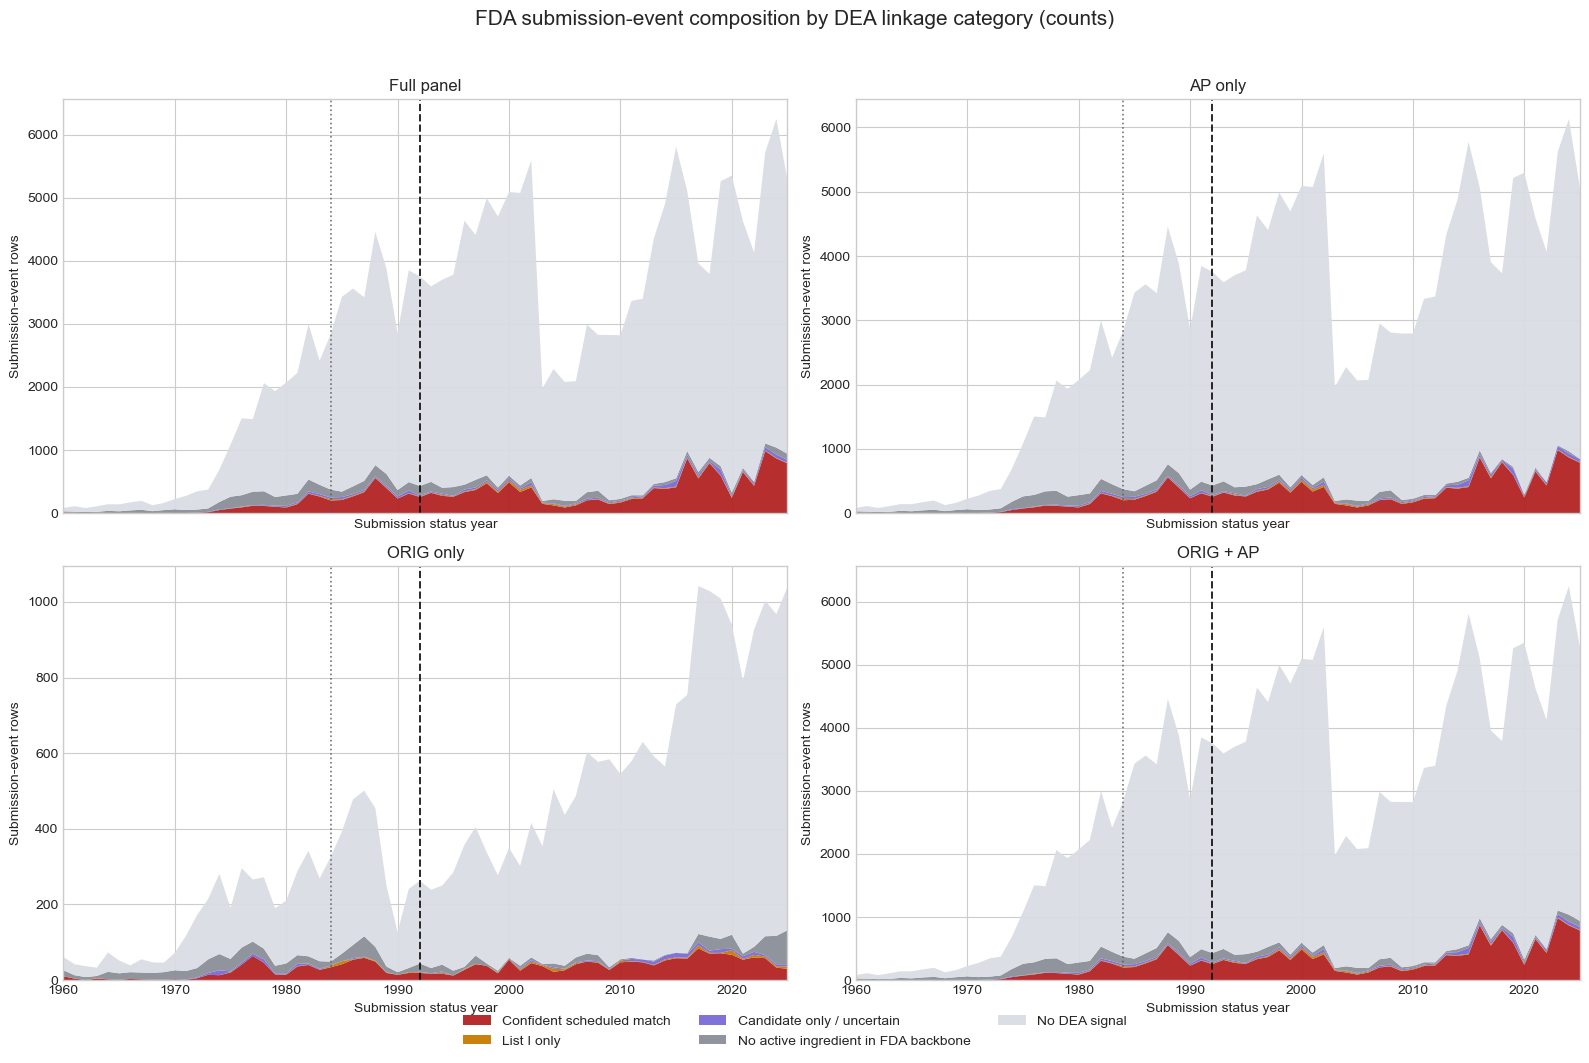

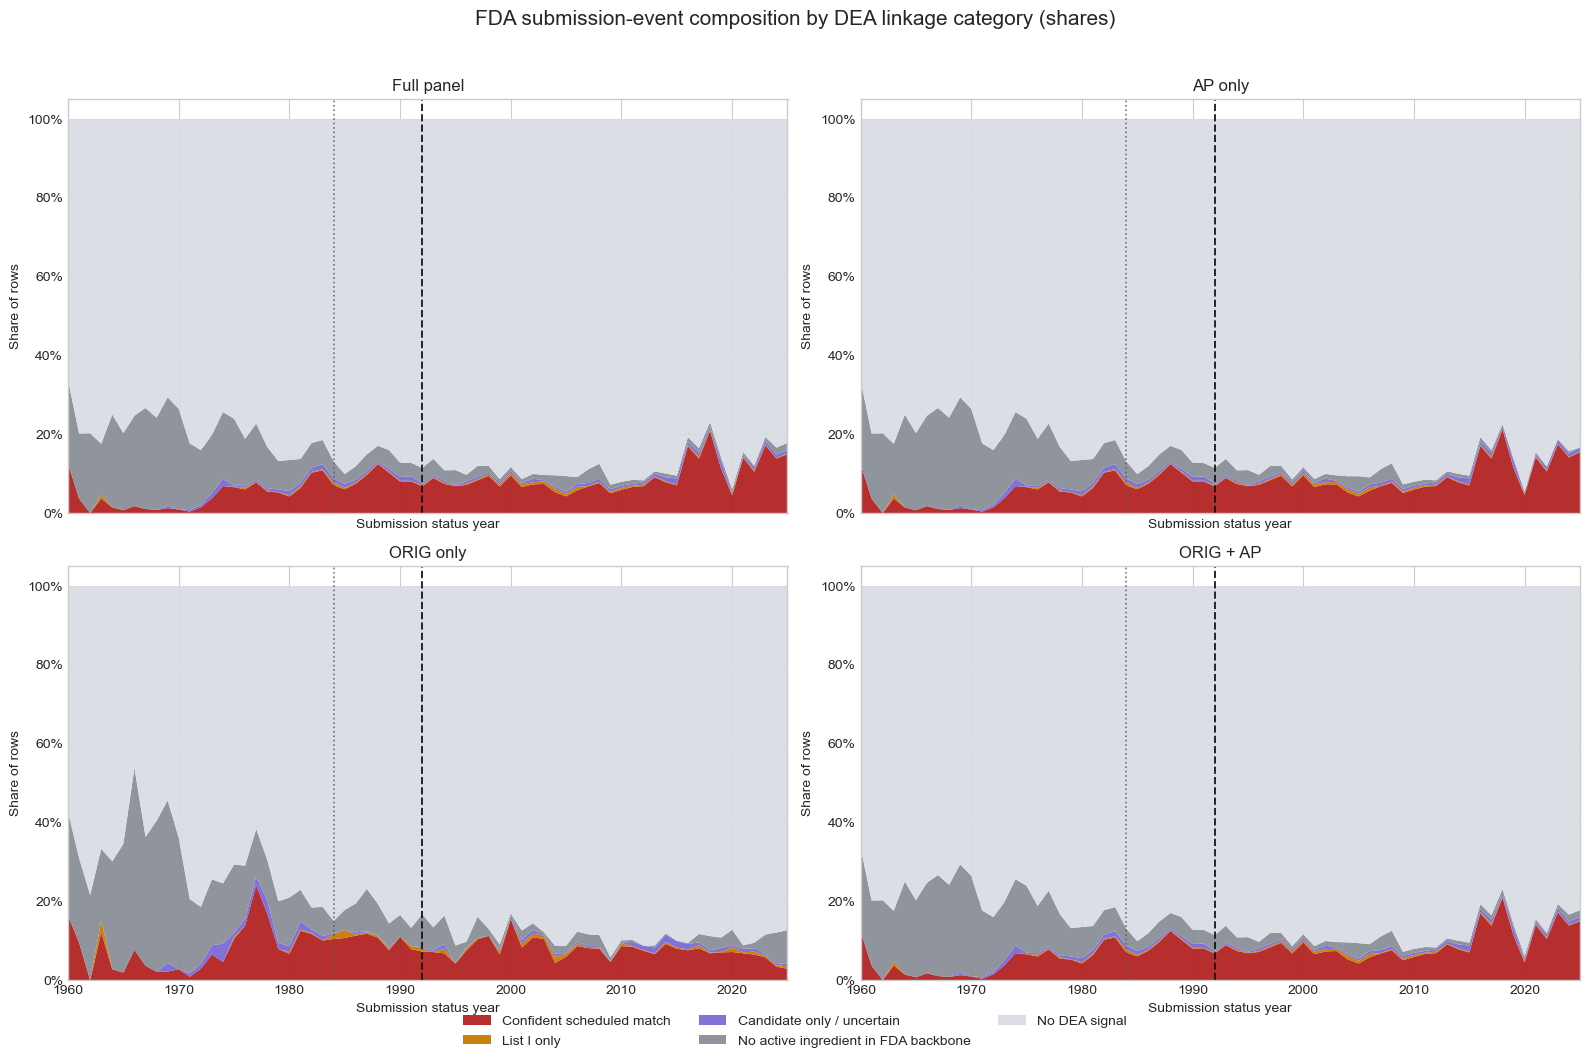

In [6]:
plot_stacked_linkage_panels(["full_panel", "ap_only", "orig_only", "orig_plus_ap"], share=False)
plt.show()

plot_stacked_linkage_panels(["full_panel", "ap_only", "orig_only", "orig_plus_ap"], share=True)
plt.show()


### Interpretation

The yearly panels are mainly useful for comparing **denominator choice**.

- The full panel and `AP` subset look very similar because `AP` rows dominate the FDA backbone.
- `ORIG + AP` also looks very close to `AP`, which means it does not add much independent information as a primary series.
- `ORIG` is visibly different because it strips out most supplement volume. That makes it a more defensible lens if the thesis wants a series closer to new application activity rather than total regulatory churn.

The figures also show why the notebook should not use a single broad “DEA yes/no” measure too early: the confident signal, the uncertain candidate signal, the missing-ingredient rows, and the no-signal rows behave differently over time.


## Application-type decomposition

A PDUFA-focused thesis cannot rely only on the broad sample definitions because `NDA`, `ANDA`, and `BLA` do not serve the same policy role. The next block therefore looks at how the **confident scheduled-match signal** behaves across application types.

The requested emphasis was on `AP` and `ORIG + AP`. After inspecting the sample counts, `ORIG + AP` is almost identical to `AP`, so the more informative contrast is:

- `AP` only: the broad approval-centered view
- `ORIG` only: the cleaner view that reduces supplement inflation

That choice is documented rather than hidden.


,sample,rows,share_of_full_panel,difference_from_ap_rows
0,AP only,190051,0.9937,0
1,ORIG + AP,191217,0.9997,1166


,appl_type_label,dea_linkage_status_work,row_count,share_within_application_type
0,ANDA,confident_scheduled_controlled_substance_match,13029,0.1310
1,ANDA,list_i_chemical_only_match,229,0.0023
2,ANDA,possible_parent_or_isomer_candidate_only,686,0.0069
3,ANDA,no_active_ingredient_available_in_fda_backbone,370,0.0037
4,ANDA,no_dea_signal_from_first_pass,85127,0.8561
5,BLA,confident_scheduled_controlled_substance_match,0,0.0000
6,BLA,list_i_chemical_only_match,0,0.0000
7,BLA,possible_parent_or_isomer_candidate_only,154,0.0278
8,BLA,no_active_ingredient_available_in_fda_backbone,2,0.0004
9,BLA,no_dea_signal_from_first_pass,5392,0.9719


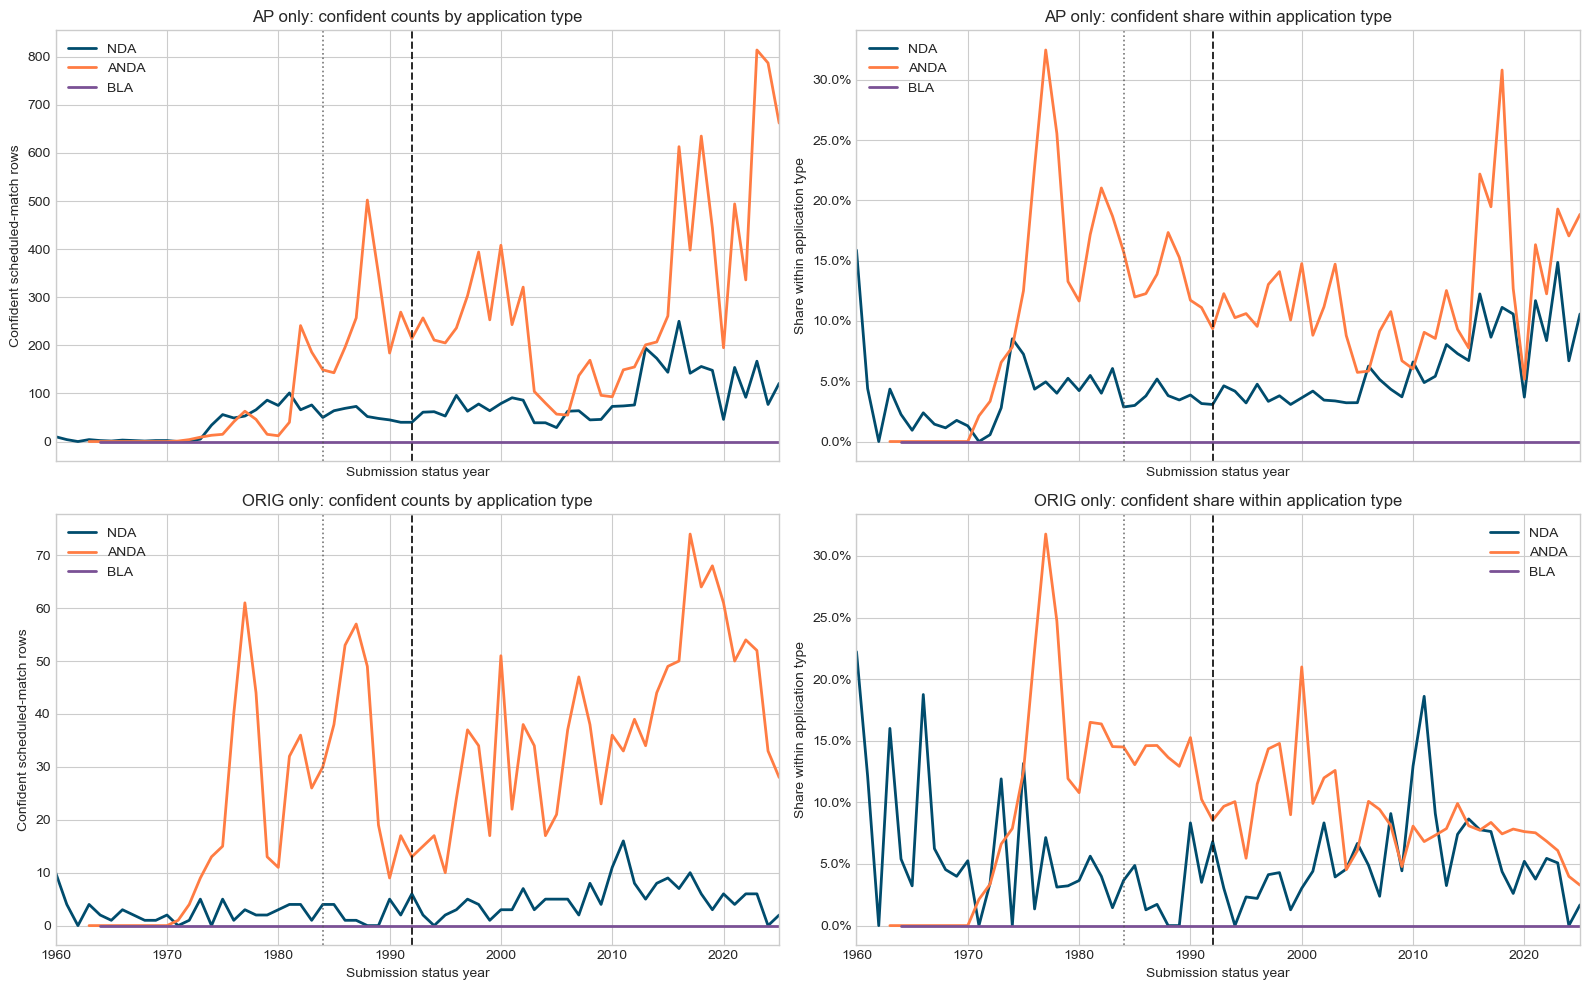

In [7]:
ap_vs_origap_comparison = pd.DataFrame([
    {
        "sample": "AP only",
        "rows": int(np.sum(SAMPLE_DEFINITIONS["ap_only"]["mask"])),
        "share_of_full_panel": np.sum(SAMPLE_DEFINITIONS["ap_only"]["mask"]) / len(analysis_df),
    },
    {
        "sample": "ORIG + AP",
        "rows": int(np.sum(SAMPLE_DEFINITIONS["orig_plus_ap"]["mask"])),
        "share_of_full_panel": np.sum(SAMPLE_DEFINITIONS["orig_plus_ap"]["mask"]) / len(analysis_df),
    },
])
ap_vs_origap_comparison["difference_from_ap_rows"] = ap_vs_origap_comparison["rows"] - ap_vs_origap_comparison.loc[0, "rows"]

overall_appltype_linkage_share = (
    analysis_df.loc[analysis_df["appl_type_label"].isin(["NDA", "ANDA", "BLA"])]
    .groupby(["appl_type_label", "dea_linkage_status_work"], observed=False)
    .size()
    .rename("row_count")
    .reset_index()
)
overall_appltype_linkage_share["share_within_application_type"] = (
    overall_appltype_linkage_share.groupby("appl_type_label")["row_count"]
    .transform(lambda s: s / s.sum())
)

display(ap_vs_origap_comparison)
display(overall_appltype_linkage_share)

plot_confident_appltype_panels(["ap_only", "orig_only"])
plt.show()


### Interpretation

The application-type decomposition is central for thesis design.

The confident scheduled-match rows are much more concentrated in `ANDA` than in `NDA`, especially in the broader approval-centered samples. That matters because a PDUFA story is more naturally about `NDA` / `BLA` review behavior than about generic approvals created by Hatch-Waxman and later generic activity.

This creates a real tradeoff:

- broad all-application samples are larger and smoother
- `NDA`-focused samples are closer to the institutional mechanism but much smaller and noisier

The notebook should carry that tradeoff explicitly into the outcome-recommendation section rather than pretending one series is automatically correct.


## Sensitivity of the yearly outcome series to DEA confidence tiers

The next question is whether the substantive picture changes when the DEA linkage is broadened.

The four comparison tiers are:

- confident scheduled match only
- confident scheduled + `List I`
- confident scheduled + candidate-only uncertain matches
- any DEA signal at all

A careful thesis should know whether the main result is driven by classification choice or whether the broad story is similar across reasonable tiers.


,sample_label,tier_label,mean_yearly_rows,mean_yearly_share,share_sd,share_cv,mean_share_1980_1992,mean_share_1993_2005,post_minus_pre
0,AP only,Confident scheduled only,362.2391,0.0893,0.0372,0.4172,0.0825,0.0730,-0.0095
1,AP only,Confident + List I,375.0652,0.0928,0.0366,0.3939,0.0857,0.0778,-0.0079
2,AP only,Confident + candidate-only,391.4783,0.0967,0.0379,0.3920,0.0912,0.0782,-0.0130
3,AP only,Any DEA signal,404.3043,0.1003,0.0372,0.3709,0.0944,0.0830,-0.0114
4,ORIG only,Confident scheduled only,40.1304,0.0822,0.0254,0.3091,0.0997,0.0839,-0.0158
5,ORIG only,Confident + List I,42.7391,0.0873,0.0256,0.2936,0.1054,0.0901,-0.0153
6,ORIG only,Confident + candidate-only,43.6957,0.0886,0.0260,0.2928,0.1054,0.0886,-0.0168
7,ORIG only,Any DEA signal,46.3043,0.0938,0.0261,0.2783,0.1111,0.0948,-0.0163
8,"AP, NDA only",Confident scheduled only,85.7391,0.0558,0.0292,0.5226,0.0399,0.0369,-0.0030
9,"AP, NDA only",Confident + List I,93.6739,0.0607,0.0286,0.4705,0.0435,0.0443,0.0008


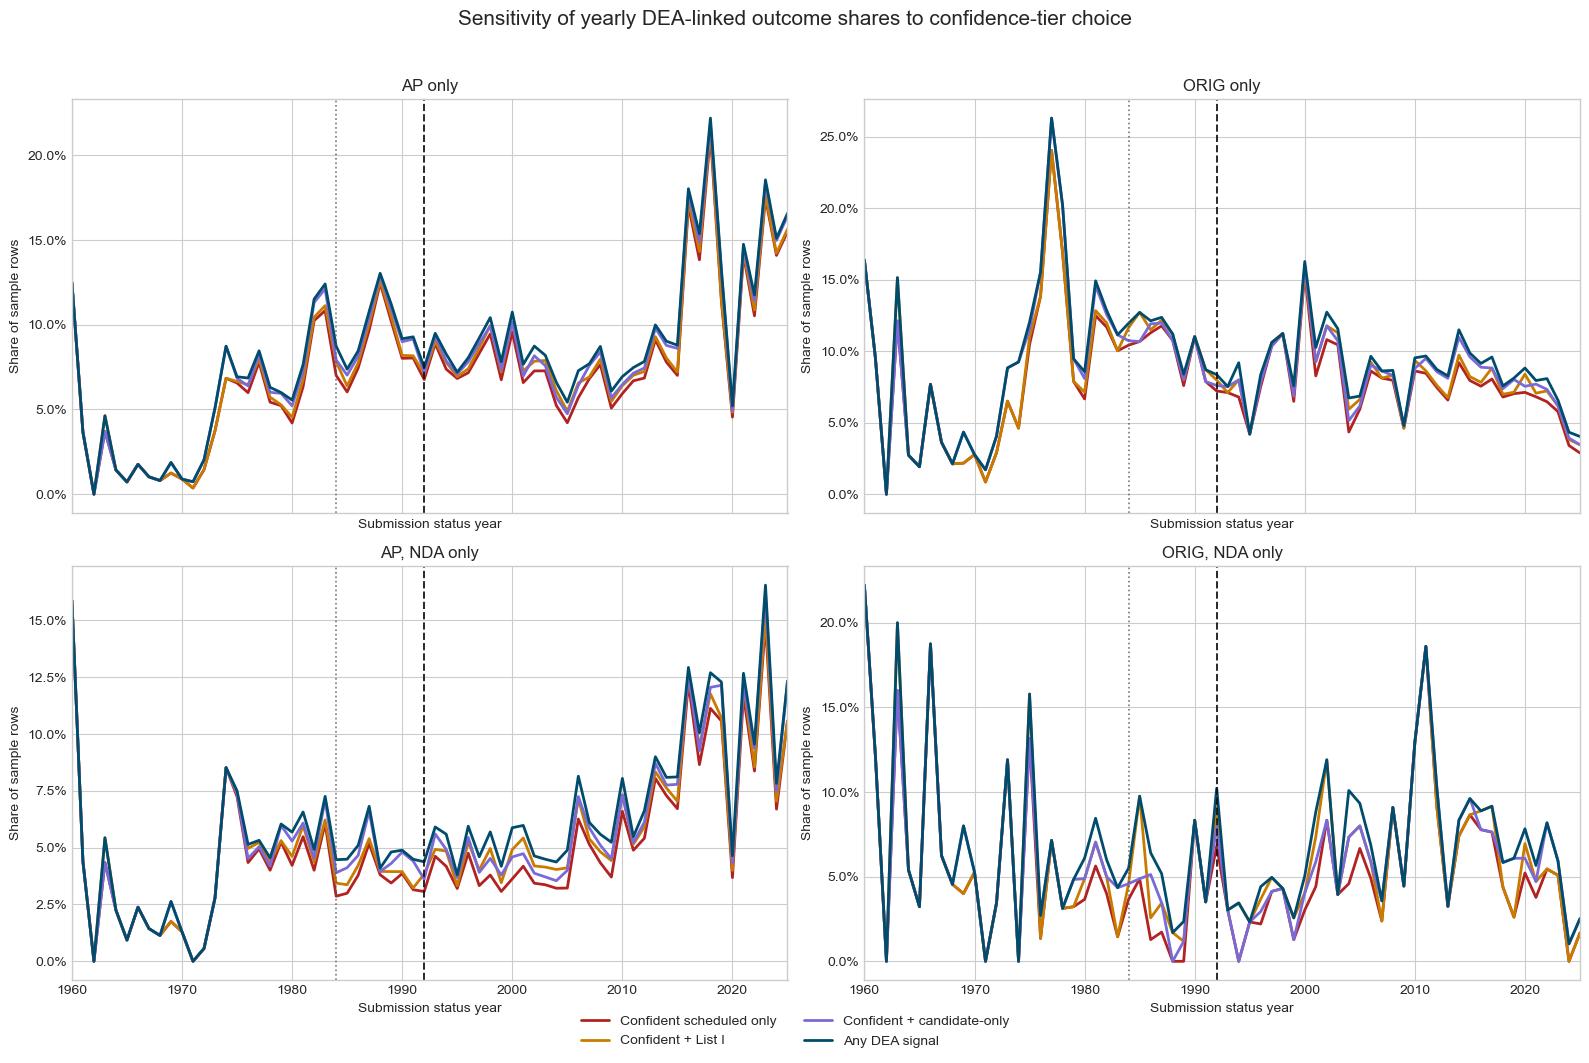

In [8]:
TIER_LABELS = OrderedDict([
    ("confident_only", "Confident scheduled only"),
    ("confident_plus_list_i", "Confident + List I"),
    ("confident_plus_candidate", "Confident + candidate-only"),
    ("any_dea_signal", "Any DEA signal"),
])

tier_comparison_table = []
for sample_key, spec in FOCUSED_SAMPLE_DEFINITIONS.items():
    for tier_name, tier_label in TIER_LABELS.items():
        yearly = yearly_tier_series(spec["mask"], tier_name)
        yearly = yearly.loc[(yearly.index >= 1980) & (yearly.index <= 2025)]
        tier_comparison_table.append({
            "sample_label": spec["label"],
            "tier_label": tier_label,
            "mean_yearly_rows": yearly["tier_rows"].mean(),
            "mean_yearly_share": yearly["tier_share"].mean(),
            "share_sd": yearly["tier_share"].std(),
            "share_cv": yearly["tier_share"].std() / yearly["tier_share"].mean() if yearly["tier_share"].mean() else np.nan,
            "mean_share_1980_1992": yearly.loc[1980:1992, "tier_share"].mean(),
            "mean_share_1993_2005": yearly.loc[1993:2005, "tier_share"].mean(),
            "post_minus_pre": yearly.loc[1993:2005, "tier_share"].mean() - yearly.loc[1980:1992, "tier_share"].mean(),
        })

tier_comparison_table = pd.DataFrame(tier_comparison_table)
display(tier_comparison_table)

plot_tier_comparison_panels(FOCUSED_SAMPLE_DEFINITIONS, TIER_LABELS)
plt.show()


### Interpretation

The confidence-tier comparison helps separate two questions:

1. which **sample definition** is least misleading?
2. which **DEA linkage rule** is least fragile?

If the broad story changes only modestly when moving from “confident only” to broader DEA-signal definitions, that argues for using the confident series in the main text and reserving broader definitions for sensitivity checks. If the story changes sharply, the thesis should treat the linkage choice as a central uncertainty rather than a footnote.

The figures and table above also make clear that a small `NDA`-only sample can be conceptually attractive but empirically noisier than an all-application series.


## Missingness and uncertainty diagnostics

A later event-study notebook should not be built until the weak points of the linkage are visible. This section therefore summarizes three analytically distinct problems:

- rows with no FDA-side ingredient information
- rows with an observed ingredient string but no DEA signal
- rows with only a candidate / uncertain DEA signal

The token-level audit from notebook 03 is used here only for diagnostic detail, not to redefine the linkage itself.


In [9]:
diagnostic_summary = pd.concat([
    summarize_by_sample("dea_linkage_status_work", order=DEA_STATUS_ORDER, labels=DEA_STATUS_LABELS),
], ignore_index=True)

no_ingredient_by_appltype = count_share_table(
    analysis_df.loc[analysis_df["dea_linkage_status_work"] == "no_active_ingredient_available_in_fda_backbone"],
    "appl_type_label",
    order=["NDA", "ANDA", "BLA", "UNKNOWN"],
)

candidate_only_examples = (
    analysis_df.loc[analysis_df["dea_linkage_status_work"] == "possible_parent_or_isomer_candidate_only", "ActiveIngredient_list"]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("ActiveIngredient_list")
    .reset_index(name="submission_event_rows")
)

unmatched_token_mask = (
    token_audit["dea_confident_match_flag"].fillna(False).eq(False)
    & token_audit["dea_list_i_only_flag"].fillna(False).eq(False)
    & token_audit["dea_possible_match_method"].isna()
)

unmatched_token_examples = (
    token_audit.loc[unmatched_token_mask, "fda_ingredient_token_raw"]
    .value_counts(dropna=False)
    .head(25)
    .rename_axis("fda_ingredient_token_raw")
    .reset_index(name="token_rows")
)

display(diagnostic_summary)
display(no_ingredient_by_appltype)
display(candidate_only_examples)
display(unmatched_token_examples)


,sample_key,sample_label,dea_linkage_status_work,row_count,share,label
0,full_panel,Full panel,confident_scheduled_controlled_substance_match,17395,0.0909,Confident scheduled match
1,full_panel,Full panel,list_i_chemical_only_match,614,0.0032,List I only
2,full_panel,Full panel,possible_parent_or_isomer_candidate_only,1421,0.0074,Candidate only / uncertain
3,full_panel,Full panel,no_active_ingredient_available_in_fda_backbone,5737,0.0300,No active ingredient in FDA backbone
4,full_panel,Full panel,no_dea_signal_from_first_pass,166098,0.8684,No DEA signal
5,ap_only,AP only,confident_scheduled_controlled_substance_match,17345,0.0913,Confident scheduled match
6,ap_only,AP only,list_i_chemical_only_match,609,0.0032,List I only
7,ap_only,AP only,possible_parent_or_isomer_candidate_only,1417,0.0075,Candidate only / uncertain
8,ap_only,AP only,no_active_ingredient_available_in_fda_backbone,5353,0.0282,No active ingredient in FDA backbone
9,ap_only,AP only,no_dea_signal_from_first_pass,165327,0.8699,No DEA signal


,appl_type_label,row_count,share
2,NDA,23,0.0040
1,ANDA,370,0.0645
3,BLA,2,0.0003
0,UNKNOWN,5342,0.9311


,ActiveIngredient_list,submission_event_rows
0,DEXTROAMPHETAMINE SULFATE,216
1,DEXMETHYLPHENIDATE HYDROCHLORIDE,154
2,METHYLTESTOSTERONE,129
3,BUTABARBITAL SODIUM,124
4,ESZOPICLONE,71
5,TESTOSTERONE ENANTHATE,59
6,DEXTROSE; MAGNESIUM CHLORIDE; POTASSIUM CHLORI...,54
7,INSULIN ASPART RECOMBINANT,53
8,INSULIN ASPART PROTAMINE RECOMBINANT; INSULIN ...,43
9,MAGNESIUM SULFATE; POTASSIUM CHLORIDE; POTASSI...,37


,fda_ingredient_token_raw,token_rows
0,SODIUM CHLORIDE,70
1,POTASSIUM CHLORIDE,58
2,DEXTROSE,41
3,MAGNESIUM CHLORIDE,40
4,HYDROCHLOROTHIAZIDE,39
5,LAMIVUDINE,33
6,AMINO ACIDS,29
7,METFORMIN HYDROCHLORIDE,29
8,CALCIUM CHLORIDE,27
9,SODIUM ACETATE,26


### Interpretation

These diagnostics matter because “not matched” is not a single concept.

- `no active ingredient available` is an FDA-backbone information problem
- `candidate only` is a DEA-linkage uncertainty problem
- `no DEA signal` means an observed ingredient string did not match the current DEA reference under the first-pass rules

The token-level unmatched list is especially useful for deciding whether a future refinement would mainly recover true controlled substances or mostly add noise through aggressive normalization. That is why the notebook keeps candidate-only and no-signal rows separate rather than absorbing them into a broad uncontrolled category.


## Candidate outcome evaluation for the next event-study notebook

The notebook now compares a short list of candidate yearly outcome series. The point is not to let a single metric mechanically choose the answer, but to force the tradeoffs into one visible table.

The candidate series below vary along three dimensions:

- sample definition
- application-type restriction
- DEA confidence tier

A useful event-study outcome should be interpretable, reasonably stable, and not obviously dominated by supplement inflation or by the noisiest linkage categories.


In [10]:
CANDIDATE_SPECS = [
    {
        "candidate_label": "Share of confident scheduled matches within ORIG subset",
        "sample_mask": SAMPLE_DEFINITIONS["orig_only"]["mask"],
        "sample_note": "reduces supplement inflation; keeps all application types",
        "tier_name": "confident_only",
        "supplement_inflation_risk": "lower",
        "linkage_uncertainty_risk": "lower",
    },
    {
        "candidate_label": "Share of confident scheduled matches within AP subset",
        "sample_mask": SAMPLE_DEFINITIONS["ap_only"]["mask"],
        "sample_note": "approval-centered but supplement-heavy",
        "tier_name": "confident_only",
        "supplement_inflation_risk": "high",
        "linkage_uncertainty_risk": "lower",
    },
    {
        "candidate_label": "Share of confident scheduled matches within ORIG, NDA-only subset",
        "sample_mask": FOCUSED_SAMPLE_DEFINITIONS["orig_nda"]["mask"],
        "sample_note": "closest to a PDUFA-mechanism lens but much smaller",
        "tier_name": "confident_only",
        "supplement_inflation_risk": "lower",
        "linkage_uncertainty_risk": "lower",
    },
    {
        "candidate_label": "Share of any DEA signal within ORIG subset",
        "sample_mask": SAMPLE_DEFINITIONS["orig_only"]["mask"],
        "sample_note": "reduces supplement inflation but absorbs uncertain linkage cases",
        "tier_name": "any_dea_signal",
        "supplement_inflation_risk": "lower",
        "linkage_uncertainty_risk": "higher",
    },
    {
        "candidate_label": "Share of confident + List I matches within ORIG subset",
        "sample_mask": SAMPLE_DEFINITIONS["orig_only"]["mask"],
        "sample_note": "still excludes candidate-only cases but mixes scheduled drugs and List I chemicals",
        "tier_name": "confident_plus_list_i",
        "supplement_inflation_risk": "lower",
        "linkage_uncertainty_risk": "medium",
    },
]

candidate_metrics = []
for spec in CANDIDATE_SPECS:
    yearly = yearly_tier_series(spec["sample_mask"], spec["tier_name"]).loc[1980:2025]
    candidate_metrics.append({
        "candidate_label": spec["candidate_label"],
        "sample_note": spec["sample_note"],
        "supplement_inflation_risk": spec["supplement_inflation_risk"],
        "linkage_uncertainty_risk": spec["linkage_uncertainty_risk"],
        "mean_yearly_denominator_rows": yearly["total_rows"].mean(),
        "mean_yearly_numerator_rows": yearly["tier_rows"].mean(),
        "mean_yearly_share": yearly["tier_share"].mean(),
        "share_sd": yearly["tier_share"].std(),
        "share_cv": yearly["tier_share"].std() / yearly["tier_share"].mean() if yearly["tier_share"].mean() else np.nan,
        "mean_share_1980_1992": yearly.loc[1980:1992, "tier_share"].mean(),
        "mean_share_1993_2005": yearly.loc[1993:2005, "tier_share"].mean(),
        "post_minus_pre": yearly.loc[1993:2005, "tier_share"].mean() - yearly.loc[1980:1992, "tier_share"].mean(),
    })

candidate_metrics = pd.DataFrame(candidate_metrics).sort_values(["share_cv", "mean_yearly_denominator_rows"], ascending=[True, False])
display(candidate_metrics)


,candidate_label,sample_note,supplement_inflation_risk,linkage_uncertainty_risk,mean_yearly_denominator_rows,mean_yearly_numerator_rows,mean_yearly_share,share_sd,share_cv,mean_share_1980_1992,mean_share_1993_2005,post_minus_pre
3,Share of any DEA signal within ORIG subset,reduces supplement inflation but absorbs uncer...,lower,higher,522.9130,46.3043,0.0938,0.0261,0.2783,0.1111,0.0948,-0.0163
4,Share of confident + List I matches within ORI...,still excludes candidate-only cases but mixes ...,lower,medium,522.9130,42.7391,0.0873,0.0256,0.2936,0.1054,0.0901,-0.0153
0,Share of confident scheduled matches within OR...,reduces supplement inflation; keeps all applic...,lower,lower,522.9130,40.1304,0.0822,0.0254,0.3091,0.0997,0.0839,-0.0158
1,Share of confident scheduled matches within AP...,approval-centered but supplement-heavy,high,lower,"3,855.6304",362.2391,0.0893,0.0372,0.4172,0.0825,0.0730,-0.0095
2,Share of confident scheduled matches within OR...,closest to a PDUFA-mechanism lens but much sma...,lower,lower,92.9130,4.4348,0.0473,0.0351,0.7413,0.0346,0.0371,0.0025


### Interpretation and recommendation

The candidate table is the decision point for the notebook.

A defensible primary outcome for the next event-study notebook should satisfy four conditions:

1. it should not be mechanically driven by supplement growth
2. it should rely on the **confident** DEA tier in the main specification
3. it should have a denominator large enough to avoid extreme volatility
4. it should stay conceptually close to the thesis question about the composition of FDA activity

The strongest candidate under those criteria is:

**Primary recommendation:** use the **annual share of confident scheduled-match rows within the `ORIG` subset** as the main controlled-substance outcome series for the next notebook.

Why this is the most defensible next step:

- `ORIG` reduces supplement inflation much more than `AP` or `ORIG + AP`
- the confident tier avoids folding uncertain candidate matches into the main series
- the yearly denominator is much larger and more stable than the `ORIG, NDA-only` denominator
- the resulting series stays closer to the composition of original FDA submission activity than the supplement-heavy approval-centered alternatives

A disciplined secondary analysis should still follow:

- `ORIG, NDA-only` as the mechanism-aligned sensitivity if the thesis wants a tighter PDUFA lens
- broader DEA-signal definitions in appendix-style sensitivity checks rather than in the main specification


## Final synthesis and suggested next step

### What this notebook found

- The FDA backbone remains overwhelmingly approval-centered, so the full panel and `AP` subset look very similar.
- `ORIG + AP` adds little independent information beyond `AP` because the overlap is so large.
- The confident DEA-linked signal is real and nontrivial, but it is still a minority share of submission-event activity.
- The confident signal is much more concentrated in `ANDA` than in `NDA`, which complicates any simple PDUFA interpretation based on all application types together.
- Rows with missing active ingredients, candidate-only matches, and no DEA signal are substantively different and should remain separated.

### What seems robust versus what looks fragile

More robust:

- the broad ranking of sample definitions: `ORIG` is cleaner than `AP` for composition work because it reduces supplement inflation
- the broad ranking of DEA tiers: confident-only is the cleanest main-text definition
- the similarity between the full panel, `AP`, and `ORIG + AP`

More fragile:

- any series that tries to read current DEA linkage as historical schedule-at-approval
- any outcome that absorbs candidate-only matches into the main treatment definition
- any PDUFA story that ignores how strongly the controlled-substance signal is tied to `ANDA`
- very small `NDA`-only series, which are conceptually attractive but empirically noisy

### Most appropriate sample definition going forward

For the next notebook, the best primary sample is the **`ORIG` subset**, paired with the **confident scheduled-match** DEA tier.

That does **not** mean the `AP` or `NDA` views should disappear. It means they should be treated as structured comparisons or sensitivity checks rather than as the default main outcome series.

### Suggested next notebook

The next notebook should be a dedicated **event-study setup notebook** that:

1. starts from the `ORIG` subset of the FDA backbone
2. uses the annual share of confident scheduled DEA matches as the primary outcome series
3. carries `ORIG, NDA-only` and broader DEA-signal variants as sensitivity outcomes
4. documents the event-study window, treatment timing, and denominator choice explicitly before any estimation begins
